In [1]:
# Gymnasium 설치 (OpenAI Gym의 최신 버전)
!pip install -q gymnasium[classic-control]
!pip install -q pygame

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 135.5 MB/s eta 0:00:00


In [1]:
# 기본 라이브러리 임포트
import numpy as np  # 수치 계산
import matplotlib.pyplot as plt  # 시각화
import gymnasium as gym  # 강화학습 환경
from collections import deque, defaultdict  # 자료구조
import random  # 랜덤 샘플링

# PyTorch (DQN용)
import torch  # PyTorch 메인
import torch.nn as nn  # 신경망
import torch.optim as optim  # 옵티마이저
import torch.nn.functional as F  # 활성화 함수

# 시각화 스타일 설정
plt.style.use('seaborn-v0_8-darkgrid')

# 랜덤 시드 고정 (재현성)
def set_seed(seed=42):
    """모든 난수 생성기의 시드 고정"""
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

set_seed(42)

# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n 사용 디바이스: {device}")
print(f"   Gymnasium 버전: {gym.__version__}")
print(f"   PyTorch 버전: {torch.__version__}")

# 강화학습 핵심 개념
print("\n" + "=" * 60)
print("강화학습 핵심 개념")
print("=" * 60)
print("""
강화학습(Reinforcement Learning)은 Agent가 환경(Environment)과
상호작용하며 보상(Reward)을 최대화하는 방법을 학습하는 기법입니다.

┌─────────────────────────────────────────┐
│          Reinforcement Learning         │
│                                         │
│  ┌──────┐      Action       ┌──────┐    │
│  │Agent │ ────────────────> │ Env  │    │
│  │      │ <──────────────── │      │    │
│  └──────┘   State, Reward   └──────┘    │
│                                         │
└─────────────────────────────────────────┘

주요 용어:
- State (상태): 환경의 현재 상황
- Action (행동): Agent(의사결정 주체)가 취할 수 있는 행동
- Reward (보상): 행동에 대한 즉각적인 피드백
- Policy (정책): 상태에서 행동을 선택하는 전략
- Value Function (가치 함수): 상태 또는 행동의 장기적 가치
""")



 사용 디바이스: cpu
   Gymnasium 버전: 1.3.0
   PyTorch 버전: 2.11.0+cpu

강화학습 핵심 개념

강화학습(Reinforcement Learning)은 Agent가 환경(Environment)과
상호작용하며 보상(Reward)을 최대화하는 방법을 학습하는 기법입니다.

┌─────────────────────────────────────────┐
│          Reinforcement Learning         │
│                                         │
│  ┌──────┐      Action       ┌──────┐    │
│  │Agent │ ────────────────> │ Env  │    │
│  │      │ <──────────────── │      │    │
│  └──────┘   State, Reward   └──────┘    │
│                                         │
└─────────────────────────────────────────┘

주요 용어:
- State (상태): 환경의 현재 상황
- Action (행동): Agent(의사결정 주체)가 취할 수 있는 행동
- Reward (보상): 행동에 대한 즉각적인 피드백
- Policy (정책): 상태에서 행동을 선택하는 전략
- Value Function (가치 함수): 상태 또는 행동의 장기적 가치



In [3]:
# FrozenLake 환경 생성
print("\n FrozenLake-v1 환경:")
print("   목표: 얼어붙은 호수를 건너 목표 지점(G)에 도달")
print("   맵 구조:")
print("   S: 시작점 (Start)")
print("   F: 얼음 (Frozen) - 안전")
print("   H: 구멍 (Hole) - 빠지면 실패")
print("   G: 목표 (Goal)")

env_frozen = gym.make('FrozenLake-v1', is_slippery=False, render_mode='rgb_array')
# is_slippery=False: 결정론적 환경 (초급용)

print(f"\n   관찰 공간 (State): {env_frozen.observation_space}")
print(f"   행동 공간 (Action): {env_frozen.action_space}")
print(f"   - 0: 왼쪽 (Left)")
print(f"   - 1: 아래 (Down)")
print(f"   - 2: 오른쪽 (Right)")
print(f"   - 3: 위 (Up)")

state, info = env_frozen.reset(seed=42)
# 환경 초기화(reset), state (초기 시작 상태)

total_reward = 0 # 총보상(총점수)
steps = 0        # 수행 횟수

for step in range(20):     # 최대 20 스텝
    action = env_frozen.action_space.sample()
    # random action (임의적, 무작위적으로 행동을 선택)
    next_state, reward, terminated, truncated, info = env_frozen.step(action)
    # next_state : 다음 상태 / reward (보상 +1: 목표 달성, 0: 실패)
    # terminated : (게임 성공/실패), truncated : 제한된 스텝(횟수) 20번 >> 강제 종료

    total_reward += reward
    steps += 1

    print(f'    Step {step+1}: State={state} >>> Action={action} >>>'
          f'Next State={next_state}, Reward={reward}')

    if terminated or truncated:
        print(f'    Episode 종료! 총보상: {total_reward}, steps: {step}')
        break

    state = next_state

env_frozen.close()


 FrozenLake-v1 환경:
   목표: 얼어붙은 호수를 건너 목표 지점(G)에 도달
   맵 구조:
   S: 시작점 (Start)
   F: 얼음 (Frozen) - 안전
   H: 구멍 (Hole) - 빠지면 실패
   G: 목표 (Goal)

   관찰 공간 (State): Discrete(16)
   행동 공간 (Action): Discrete(4)
   - 0: 왼쪽 (Left)
   - 1: 아래 (Down)
   - 2: 오른쪽 (Right)
   - 3: 위 (Up)
    Step 1: State=0 >>> Action=3 >>>Next State=0, Reward=0
    Step 2: State=0 >>> Action=2 >>>Next State=1, Reward=0
    Step 3: State=1 >>> Action=2 >>>Next State=2, Reward=0
    Step 4: State=2 >>> Action=1 >>>Next State=6, Reward=0
    Step 5: State=6 >>> Action=1 >>>Next State=10, Reward=0
    Step 6: State=10 >>> Action=1 >>>Next State=14, Reward=0
    Step 7: State=14 >>> Action=0 >>>Next State=13, Reward=0
    Step 8: State=13 >>> Action=2 >>>Next State=14, Reward=0
    Step 9: State=14 >>> Action=0 >>>Next State=13, Reward=0
    Step 10: State=13 >>> Action=3 >>>Next State=9, Reward=0
    Step 11: State=9 >>> Action=3 >>>Next State=5, Reward=0
    Episode 종료! 총보상: 0, steps: 10


In [4]:
# CartPole 환경 확인
print("\nCartPole-v1 환경:")
print("   목표: 막대를 수직으로 세운 채로 유지")
print("   상태: [위치, 속도, 각도, 각속도]")
print("   행동: 0=왼쪽, 1=오른쪽")
print("   보상: 매 스텝마다 +1 (최대 500)")

env_cart = gym.make('CartPole-v1', render_mode='rgb_array')
print(f"\n   관찰 공간: {env_cart.observation_space}")
print(f"   행동 공간: {env_cart.action_space}")
env_cart.close()



CartPole-v1 환경:
   목표: 막대를 수직으로 세운 채로 유지
   상태: [위치, 속도, 각도, 각속도]
   행동: 0=왼쪽, 1=오른쪽
   보상: 매 스텝마다 +1 (최대 500)

   관찰 공간: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
   행동 공간: Discrete(2)


In [5]:
# FrozenLake Q-learning

print("\n Q-learning 개념:")
print("""
Q-learning은 모델 없이(Model-free) 최적 정책을 학습하는 알고리즘입니다.

Q-value 업데이트 공식:
Q(s,a) ← Q(s,a) + α[r + γ·max Q(s',a') - Q(s,a)]

- r (reward) : 즉각적인 보상
- α (alpha): 학습률 (Learning Rate)
- γ (gamma): 할인율 (Discount Factor)
- ε (epsilon): 탐험 비율 (Exploration Rate)
""")


 Q-learning 개념:

Q-learning은 모델 없이(Model-free) 최적 정책을 학습하는 알고리즘입니다.

Q-value 업데이트 공식:
Q(s,a) ← Q(s,a) + α[r + γ·max Q(s',a') - Q(s,a)]

- r (reward) : 즉각적인 보상
- α (alpha): 학습률 (Learning Rate)
- γ (gamma): 할인율 (Discount Factor)
- ε (epsilon): 탐험 비율 (Exploration Rate)




 FrozenLake Q-learning 학습 시작:
    Episode 200/2000-Avg.Reward: 0.000, Success Rate: 0.0, epsilon: 0.367
    Episode 400/2000-Avg.Reward: 0.000, Success Rate: 0.0, epsilon: 0.135
    Episode 600/2000-Avg.Reward: 0.000, Success Rate: 0.0, epsilon: 0.049
    Episode 800/2000-Avg.Reward: 0.000, Success Rate: 0.0, epsilon: 0.018
    Episode 1000/2000-Avg.Reward: 0.000, Success Rate: 0.0, epsilon: 0.010
    Episode 1200/2000-Avg.Reward: 0.000, Success Rate: 0.0, epsilon: 0.010
    Episode 1400/2000-Avg.Reward: 0.000, Success Rate: 0.0, epsilon: 0.010
    Episode 1600/2000-Avg.Reward: 0.000, Success Rate: 0.0, epsilon: 0.010
    Episode 1800/2000-Avg.Reward: 0.000, Success Rate: 0.0, epsilon: 0.010
    Episode 2000/2000-Avg.Reward: 0.000, Success Rate: 0.0, epsilon: 0.010

 학습된 Q-table (처음 8개 상태):
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


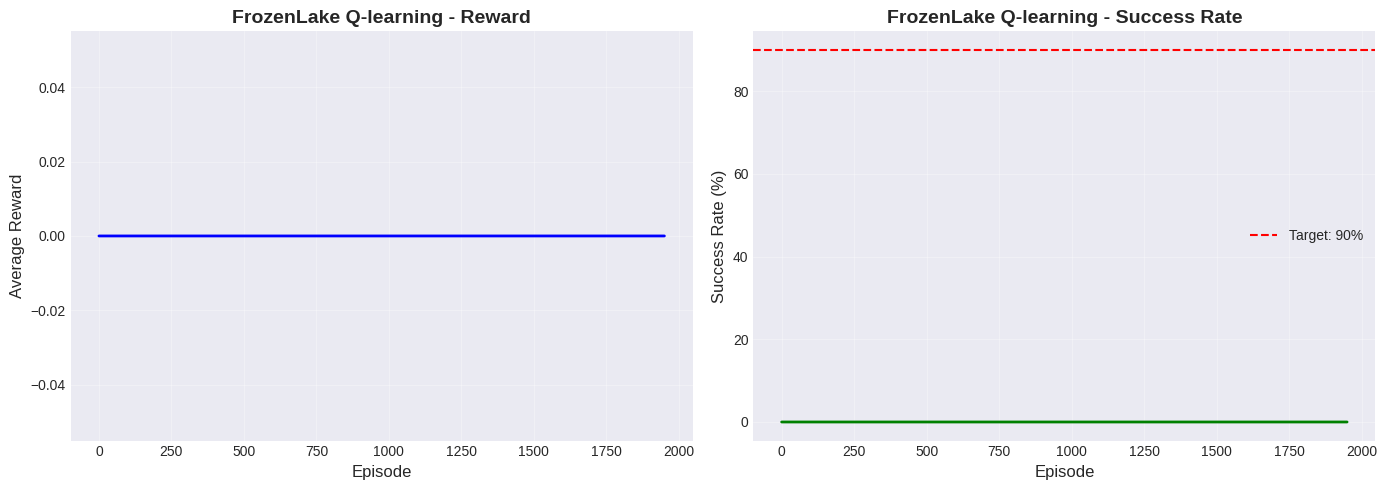

In [6]:
from math import trunc
# Q-learning Agent 클래스
class QLearningAgent:
    """
    Q-learning 에이전트
    테이블 기반으로 Q-value를 저장하고 업데이트
    이 agent 각 (상태-행동, state-action) 쌍 >> Q-value 를 2차원 배열 테이블 형태로 저장
    """
    def __init__(self, n_states, n_actions, learning_rate=0.1,
                 discount_factor=0.99, epsilon=1.0, epsilon_decay=0.995,
                 epsilon_min=0.01):
        """
        Args:
            n_states: 상태 개수
            n_actions: 행동 개수
            learning_rate: 학습률 (α)
            discount_factor: 할인율 (γ)
            epsilon: 초기 탐험 비율 (ε)
            epsilon_decay: ε 감소율
            epsilon_min: 최소 ε
        """
        self.n_states = n_states
        self.n_actions = n_actions
        self.lr = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min

        # Q-table 초기화 (모든 값을 0으로)
        self.q_table = np.zeros((n_states, n_actions))

    def get_action(self, state):
        """
        ε-greedy 정책으로 행동 선택
        Args:
            state: 현재 상태
        Returns:
            action: 선택된 행동
        """
        # 탐험(Exploration): 랜덤 행동
        if np.random.random() < self.epsilon:
            # random.random() >> [0,1] 무작위로(임의의) 수 하나 뽑기
            return np.random.randint(self.n_actions)
        # 활용(Exploitation): 최고 Q-value 행동
        else:
            return np.argmax(self.q_table[state])
            # q table에서 가장 값이 큰 행동(현재까지 있는 선택지에서 가장 좋아보이는 행동) 선택

    def update(self, state, action, reward, next_state, done):
        """
        Q-value 업데이트
        Args:
            state: 현재 상태
            action: 수행한 행동
            reward: 받은 보상
            next_state: 다음 상태
            done: 에피소드 종료 여부
        """
        # 현재 Q-value
        current_q = self.q_table[state, action]

        # TD(Time Difference, 시간차) Target 계산
        if done:   # 에피소드가 종료
            target = reward
            # 종료 상태는 미래 보상 없음
            # 지금 받는 reward 만 target(목표) 됨
        else:
            target = reward + self.gamma * np.max(self.q_table[next_state])


        # Q-value 업데이트 (TD Error 기반)
        td_error = target - current_q
        # 목표(target) - 현재 값(current_q)
        self.q_table[state, action] += self.lr * td_error
        # td_error (시간차 오차)에 학습률(lr) 곱해서 기존 q값에 더해줌
        # >> 점점 더 좋은 값으로 수렴

    def decay_epsilon(self):
        """ε 감소 (탐험 비율 줄이기)"""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)
        # epsilon이 epsilon_min보다 너무 작아지지 않게 하기 위해서 max() 써서 epsilon 업데이트 함

# FrozenLake Q-learning 학습
print("\n FrozenLake Q-learning 학습 시작:")

# 환경 및 에이전트 생성
env = gym.make('FrozenLake-v1', is_slippery=False, render_mode=None)
agent = QLearningAgent(
        n_states = env.observation_space.n,
        n_actions= env.action_space.n,
        learning_rate=0.1,
        discount_factor=0.99,
        epsilon=1.0,
        epsilon_decay=0.995,
        epsilon_min=0.01
    )

# 학습 설정
n_episodes = 2000 # episode 수 (2000번 게임 다시 시작하면서 학습)
max_steps = 100   # episode 당 최대 스텝 (1게임마다 최대 100번까지 움직임 수 있음)

rewards_history = []
success_history = []

for episode in range(n_episodes):
    state, info = env.reset()
    episode_reward = 0

    for step in range(max_steps):
        # 행동 선택
        action = agent.get_action(state)

        # 환경에서 행동 수행
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Q-value update
        agent.update(state, action, reward, next_state, done)

        episode_reward += reward
        state = next_state

        if done:
            break

    # epsilon 감소
    agent.decay_epsilon()

    rewards_history.append(episode_reward)
    success_history.append(1 if episode_reward > 0 else 0)

    # 200 episode 마다 진행상황 출력
    if (episode + 1) % 200 == 0 :
        avg_reward = np.mean(rewards_history[-100:])
        # 최근 100개 에피소드
        success_rate = np.mean(success_history[-100:]) * 100
        print(f"    Episode {episode+1}/{n_episodes}-"
              f"Avg.Reward: {avg_reward:.3f}, "
              f"Success Rate: {success_rate:.1f}, "
              f"epsilon: {agent.epsilon:.3f}"

        )
env.close()

print("\n 학습된 Q-table (처음 8개 상태):")
print(agent.q_table[:8])

# 학습 곡선 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 보상 그래프
window = 50
rewards_smooth = np.convolve(rewards_history, np.ones(window)/window, mode='valid')
# np.convolve: convolve를 활용한 이동 평균
# mode='valid' 이동하는 window를 통해 유효한 성공률 확인 (최근 50번의 에피소드 중 평균 성공률)
# >> np.ones(window)/window = 0.6 >> 30번/50번 (최근 50번 에피소드 중 평균 30번 성공)
axes[0].plot(rewards_smooth, linewidth=2, color='blue')
axes[0].set_xlabel('Episode', fontsize=12)
axes[0].set_ylabel('Average Reward', fontsize=12)
axes[0].set_title('FrozenLake Q-learning - Reward', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# 성공률 그래프
success_smooth = np.convolve(success_history, np.ones(window)/window, mode='valid') * 100
axes[1].plot(success_smooth, linewidth=2, color='green')
axes[1].set_xlabel('Episode', fontsize=12)
axes[1].set_ylabel('Success Rate (%)', fontsize=12)
axes[1].set_title('FrozenLake Q-learning - Success Rate', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=90, color='red', linestyle='--', label='Target: 90%')
axes[1].legend()

plt.tight_layout()
plt.savefig('frozenlake_qlearning_results.png', dpi=150, bbox_inches='tight')
plt.show()


원래 16*16에서 랜덤하게 이동하기 때문에 Reward를 받기 어렵다.

episode를 매우 늘려야 결과를 얻을 수 있다.

In [7]:
# CartPole 환경 이해

print("\nCartPole 환경 상세:")
print("""
CartPole-v1은 고전적인 제어 문제입니다.
카트 위에 막대가 달려있고, 카트를 좌우로 움직여
막대를 수직으로 세운 채 유지하는 것이 목표입니다.

상태 공간 (4차원):
- 위치 (Position): -4.8 ~ 4.8
- 속도 (Velocity): -∞ ~ ∞
- 각도 (Angle): -0.418 ~ 0.418 라디안 (약 ±24도)
- 각속도 (Angular Velocity): -∞ ~ ∞

행동 공간:
- 0: 왼쪽으로 힘 가하기
- 1: 오른쪽으로 힘 가하기

보상:
- 매 스텝마다 +1
- 막대가 일정 각도 이상 기울거나 카트가 화면 밖으로 나가면 종료
- 최대 500 스텝

종료 조건:
1. 막대 각도가 ±12도 초과
2. 카트 위치가 ±2.4 초과
3. 500 스텝 도달 (성공!)
""")


CartPole 환경 상세:

CartPole-v1은 고전적인 제어 문제입니다.
카트 위에 막대가 달려있고, 카트를 좌우로 움직여
막대를 수직으로 세운 채 유지하는 것이 목표입니다.

상태 공간 (4차원):
- 위치 (Position): -4.8 ~ 4.8
- 속도 (Velocity): -∞ ~ ∞
- 각도 (Angle): -0.418 ~ 0.418 라디안 (약 ±24도)
- 각속도 (Angular Velocity): -∞ ~ ∞

행동 공간:
- 0: 왼쪽으로 힘 가하기
- 1: 오른쪽으로 힘 가하기

보상:
- 매 스텝마다 +1
- 막대가 일정 각도 이상 기울거나 카트가 화면 밖으로 나가면 종료
- 최대 500 스텝

종료 조건:
1. 막대 각도가 ±12도 초과
2. 카트 위치가 ±2.4 초과
3. 500 스텝 도달 (성공!)



In [8]:
env = gym.make('CartPole-v1', render_mode=None)
state, info = env.reset(seed=42)
# 초기 상태
state
# [ 위치, 속도, 각도, 각속도 ]

array([ 0.0273956 , -0.00611216,  0.03585979,  0.0197368 ], dtype=float32)

In [9]:
# random agent 로 시뮬레이션
episode_rewards = []

for episode in range(5):
    state, info = env.reset()
    episode_reward = 0

    for step in range(500):
        action = env.action_space.sample() # randomly action
        state, reward, terminated, truncated, info = env.step(action)
        episode_reward += reward

        if terminated or truncated:
            break

    episode_rewards.append(episode_reward)
    print(f'  Episode {episode+1}: Reward={episode_reward}')

print(f" 평균 보상: {np.mean(episode_rewards)}")

env.close()

  Episode 1: Reward=31.0
  Episode 2: Reward=44.0
  Episode 3: Reward=13.0
  Episode 4: Reward=18.0
  Episode 5: Reward=35.0
 평균 보상: 28.2


In [10]:
print("\nDQN 개념:")
print("""
DQN은 Q-learning을 신경망으로 확장한 알고리즘입니다.

핵심 아이디어:
1. Q-table 대신 신경망으로 Q-value 근사
2. Experience Replay: 과거 경험을 버퍼에 저장하고 랜덤 샘플링
3. Target Network: 안정적인 학습을 위해 타겟 네트워크 별도 사용

DQN 구조:
┌─────────────────────────────────────────┐
│  State → [NN] → Q-values for all actions│
│                                         │
│  예: [0.5, 1.2, 0.8] → Choose action 1  │
└─────────────────────────────────────────┘
""")


DQN 개념:

DQN은 Q-learning을 신경망으로 확장한 알고리즘입니다.

핵심 아이디어:
1. Q-table 대신 신경망으로 Q-value 근사
2. Experience Replay: 과거 경험을 버퍼에 저장하고 랜덤 샘플링
3. Target Network: 안정적인 학습을 위해 타겟 네트워크 별도 사용

DQN 구조:
┌─────────────────────────────────────────┐
│  State → [NN] → Q-values for all actions│
│                                         │
│  예: [0.5, 1.2, 0.8] → Choose action 1  │
└─────────────────────────────────────────┘



In [11]:
# DQN  신경망 정의
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        # state_dim: 상태 차원, action_dim: 행동 개수, hidden_dim: 은닉층 뉴런 수
        super(DQN, self).__init__()

        # 3층 완전연결 네트워크
        self.fc1 = nn.Linear(state_dim, hidden_dim)   # input_dim >> hidden1
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)  # hidden1 >> hidden2
        self.fc3 = nn.Linear(hidden_dim, action_dim)  # hidden2 >> output(action)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        q_values = self.fc3(x)
        return q_values

sample_net = DQN(state_dim=4, action_dim=2, hidden_dim=128)
print(sample_net)


DQN(
  (fc1): Linear(in_features=4, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=2, bias=True)
)


In [12]:
# 파라미터 수
total_params = sum(p.numel() for p in sample_net.parameters())
total_params

17410

In [13]:
# 경험 재생 버퍼 Experience Replay Buffer
# >> 과거 경험 저장 >> 랜덤하게 샘플링

class ReplayBuffer:
    def __init__(self, capacity):
        # capacity(최대 기억용량) 버퍼 최대 크기
        self.buffer = deque(maxlen=capacity) # 최대 크기 제한
        # deque(): 꽉 차면 제일 오래된 기억부터 자동으로 지워짐

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        # batch_size : 샘플 개수
        batch = random.sample(self.buffer, batch_size)

        # batch >> tensor 변환
        # states, actions, rewards, next_states, dones
        states = torch.FloatTensor([t[0] for t in batch]) # t : tensor
        actions = torch.LongTensor([t[1] for t in batch])
        rewards = torch.FloatTensor([t[2] for t in batch])
        next_states= torch.FloatTensor([t[3] for t in batch])
        dones = torch.FloatTensor([t[4] for t in batch])

        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)

In [14]:
# 섹션 6: CartPole DQN 학습

# DQN Agent 클래스
class DQNAgent:
    """
    DQN 에이전트
    네트워크 학습 및 행동 선택 담당
    """
    def __init__(self, state_dim, action_dim, hidden_dim=128,
                 lr=0.001, gamma=0.99, epsilon=1.0, epsilon_decay=0.995,
                 epsilon_min=0.01, buffer_size=10000, batch_size=64):
        """
        Args:
            state_dim: 상태 차원
            action_dim: 행동 개수
            hidden_dim: 은닉층 크기
            lr: 학습률
            gamma: 할인율
            epsilon: 초기 탐험 비율
            epsilon_decay: ε 감소율
            epsilon_min: 최소 ε
            buffer_size: Replay Buffer 크기
            batch_size: 미니배치 크기
        """
        self.state_dim = state_dim
        self.action_dim = action_dim
        self.gamma = gamma
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.epsilon_min = epsilon_min
        self.batch_size = batch_size

        # Q-Network (학습용)
        self.q_network = DQN(state_dim, action_dim, hidden_dim).to(device)
        # Target Network (타겟 계산용) : 가끔씩만 업데이트 해야 함
        self.target_network = DQN(state_dim, action_dim, hidden_dim).to(device)
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()  # 평가 모드

        # 옵티마이저 및 손실 함수
        self.optimizer = optim.Adam(self.q_network.parameters(), lr=lr)
        self.loss_fn = nn.MSELoss()

        # Replay Buffer
        self.memory = ReplayBuffer(buffer_size)

    def get_action(self, state):
        """
        ε-greedy 정책으로 행동 선택
        Args:
            state: 현재 상태
        Returns:
            action: 선택된 행동
        """
        # 탐험
        if np.random.random() < self.epsilon:
            return np.random.randint(self.action_dim)

        # 활용 -> 학습X
        with torch.no_grad():
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
            q_values = self.q_network(state_tensor)
            action = q_values.argmax().item()
        return action

    def train(self):
        """
        미니배치 학습
        Returns:
            loss: 학습 손실
        """
        # 버퍼에 충분한 데이터가 없으면 학습 안함
        if len(self.memory) < self.batch_size:
            return 0.0

        # 미니배치 샘플링
        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)
        states = states.to(device)
        actions = actions.to(device)
        rewards = rewards.to(device)
        next_states = next_states.to(device)
        dones = dones.to(device)

        # 현재 Q-values
        current_q_values = self.q_network(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        # batch 3이라 가정, states에서 나올 수 있는 행동 2개(왼쪽, 오른쪽)
        # q_network(state).shape [3,2](batch_size, action_size)
        # [[0.1, 0.9],[0.6, 0.4],[0.4, 0.7]]
        # actions >> [1,0,1] (각 배치에서 선택한 행동 인덱스 ; q_network에서 큰 값의 인덱스) (3,)
        # actions.unsqueeze(1) (batch_size, 1) >> [3,1]  [[1],[0],[1]]
        # >> q_network(states) 때문에 (batch_size, n_actions)
        # gather(1, ...) : 열방향 (dim=1) 가로축
        # gather 차원을 맞춰줘야 함, 어떤 열을 뽑을지 알려줘야 해야함.
        # 2차원으로 늘려야 해서...
        # gather(1, actions.unsqueeze(1)) 의미하는 바는?
        # 가로축으로 인덱스 찾아서 값 추출해서 모아줘 [[0.9],[0.6],[0.7]] >> shape (3,1)
        # .squeeze(1) >> [0.9,0.6,0.7] >> shape (3,)
        # 왜? 왔다갔다리 하나요(6기 선배 컴플레인) >> TD 값이 벡터를 원해(공식에 넣어 그냥)
        # gather 때문에 2차원으로 형태 맞추고, TD에 넣기 위해 벡터로 다시 변환


        # 타겟 Q-values (Target Network 사용)
        with torch.no_grad():
            max_next_q_values = self.target_network(next_states).max(1)[0]
            # max(1)[0] 가장 높은 점수 (q_value)
            # [0]: values 해당 방향에서 가장 큰 값 q-value
            # [1]: indices 그 값이 몇 번째 위치에 있니? index(action)
            # (batch_size, n_actions) 에서 1(열방향, n_actions) 에 대해 최대값 구하고 그 인덱스 구하기
            target_q_values = rewards + (1 - dones) * self.gamma * max_next_q_values

        # 손실 계산 및 역전파
        loss = self.loss_fn(current_q_values, target_q_values)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return loss.item()

    def update_target_network(self):
        """Target Network를 Q-Network로 업데이트"""
        self.target_network.load_state_dict(self.q_network.state_dict())

    def decay_epsilon(self):
        """ε 감소"""
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)


# 에이전트 생성
env = gym.make('CartPole-v1', render_mode=None)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

agent = DQNAgent(
    state_dim=state_dim,
    action_dim=action_dim,
    hidden_dim=128,
    lr=0.001,
    gamma=0.99,
    epsilon=1.0,
    epsilon_decay=0.995,
    epsilon_min=0.01,
    buffer_size=10000,
    batch_size=64
)

In [15]:
from IPython.utils.path import target_update
# 학습
n_episodes = 500
target_update_freq = 10 # 10 episode 마다 target network update

rewards_history=[]
losses_history=[]

for episode in range(n_episodes):
    state, info = env.reset()
    episode_reward = 0
    episode_loss = 0
    steps = 0

    for step in range(500):
        # 행동 선택
        action = agent.get_action(state)

        # 환경에서 행동 수행
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Replay Buffer 저장
        agent.memory.push(state, action, reward, next_state, done)

        # 학습
        loss = agent.train()
        episode_loss += loss

        episode_reward += reward
        state = next_state
        steps += 1

        if done:
            break

        # epsilon 감소
        agent.decay_epsilon()

        # Target network update
        if (episode + 1) % target_update_freq == 0:
            agent.update_target_network()

        rewards_history.append(episode_reward)
        losses_history.append(episode_loss / steps if steps > 0 else 0)

        # 50 에피소드마다 진행상황 출력
        if (episode + 1) % 50 == 0:
            avg_reward = np.mean(rewards_history[-50:])
            avg_loss = np.mean(losses_history[-50:])
            print(f"   Episode {episode+1}/{n_episodes} - "
                f"Avg Reward: {avg_reward:.1f}, "
                f"Avg Loss: {avg_loss:.4f}, "
                f"ε: {agent.epsilon:.3f}")

env.close()


# 최종 성능
final_avg_reward = np.mean(rewards_history[-50:])
print(f"\n최종 50 에피소드 평균 보상: {final_avg_reward:.1f}")
if final_avg_reward >= 450:
    print("    우수! CartPole을 성공적으로 해결했습니다!")
elif final_avg_reward >= 300:
    print("    양호! 더 학습하면 성능이 향상될 수 있습니다.")
else:
    print("    학습 중... 에피소드를 늘리면 성능이 향상됩니다.")




/tmp/ipykernel_5189/1267666580.py:19: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  states = torch.FloatTensor([t[0] for t in batch]) # t : tensor


   Episode 50/500 - Avg Reward: 145.1, Avg Loss: 1.0334, ε: 0.010
   Episode 50/500 - Avg Reward: 142.6, Avg Loss: 1.0359, ε: 0.010
   Episode 50/500 - Avg Reward: 140.2, Avg Loss: 1.0450, ε: 0.010
   Episode 50/500 - Avg Reward: 137.7, Avg Loss: 1.0659, ε: 0.010
   Episode 50/500 - Avg Reward: 135.3, Avg Loss: 1.0834, ε: 0.010
   Episode 50/500 - Avg Reward: 132.9, Avg Loss: 1.1030, ε: 0.010
   Episode 50/500 - Avg Reward: 130.4, Avg Loss: 1.1242, ε: 0.010
   Episode 50/500 - Avg Reward: 128.0, Avg Loss: 1.1495, ε: 0.010
   Episode 50/500 - Avg Reward: 125.5, Avg Loss: 1.1738, ε: 0.010
   Episode 50/500 - Avg Reward: 123.1, Avg Loss: 1.2024, ε: 0.010
   Episode 50/500 - Avg Reward: 120.7, Avg Loss: 1.2283, ε: 0.010
   Episode 50/500 - Avg Reward: 118.2, Avg Loss: 1.2589, ε: 0.010
   Episode 50/500 - Avg Reward: 115.8, Avg Loss: 1.2919, ε: 0.010
   Episode 50/500 - Avg Reward: 113.3, Avg Loss: 1.3320, ε: 0.010
   Episode 50/500 - Avg Reward: 110.9, Avg Loss: 1.3731, ε: 0.010
   Episode

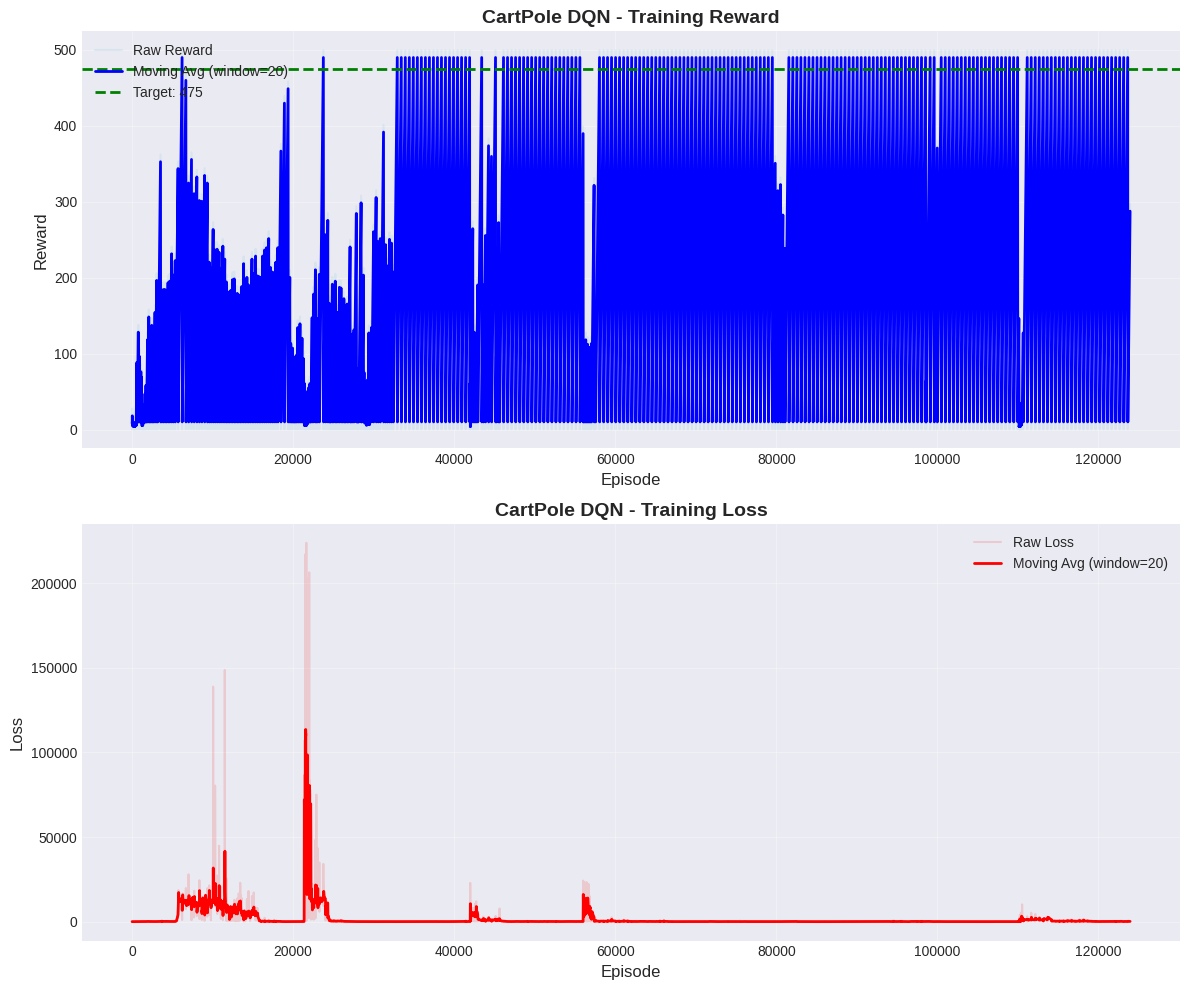


학습 결과 저장: cartpole_dqn_training.png


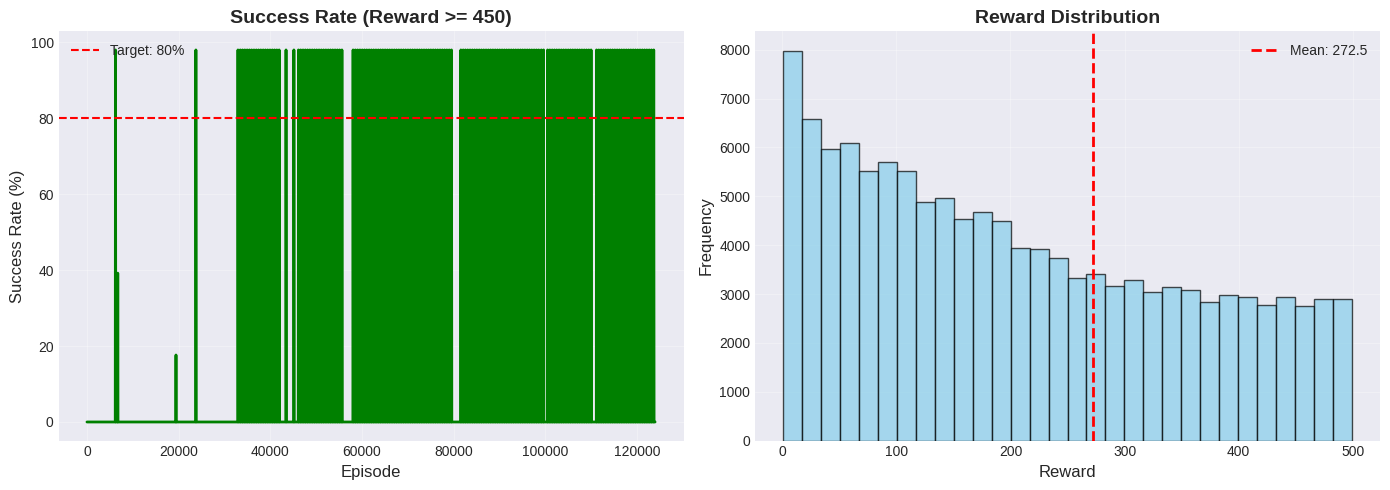

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# 보상 그래프
window = 20
rewards_smooth = np.convolve(rewards_history, np.ones(window)/window, mode='valid')
axes[0].plot(rewards_history, alpha=0.3, color='lightblue', label='Raw Reward')
axes[0].plot(range(window-1, len(rewards_history)), rewards_smooth,
            linewidth=2, color='blue', label=f'Moving Avg (window={window})')
axes[0].axhline(y=475, color='green', linestyle='--', linewidth=2, label='Target: 475')
axes[0].set_xlabel('Episode', fontsize=12)
axes[0].set_ylabel('Reward', fontsize=12)
axes[0].set_title('CartPole DQN - Training Reward', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 손실 그래프
loss_smooth = np.convolve(losses_history, np.ones(window)/window, mode='valid')
axes[1].plot(losses_history, alpha=0.3, color='lightcoral', label='Raw Loss')
axes[1].plot(range(window-1, len(losses_history)), loss_smooth,
            linewidth=2, color='red', label=f'Moving Avg (window={window})')
axes[1].set_xlabel('Episode', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('CartPole DQN - Training Loss', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cartpole_dqn_training.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n학습 결과 저장: cartpole_dqn_training.png")

# 성능 통계 그래프
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 에피소드별 성공률 (보상 >= 450)
success_threshold = 450
success_mask = np.array(rewards_history) >= success_threshold
success_rate = [np.mean(success_mask[max(0, i-50):i+1]) * 100
                for i in range(len(success_mask))]

axes[0].plot(success_rate, linewidth=2, color='green')
axes[0].set_xlabel('Episode', fontsize=12)
axes[0].set_ylabel('Success Rate (%)', fontsize=12)
axes[0].set_title('Success Rate (Reward >= 450)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=80, color='red', linestyle='--', label='Target: 80%')
axes[0].legend()

# 보상 분포 히스토그램
axes[1].hist(rewards_history, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[1].axvline(x=final_avg_reward, color='red', linestyle='--',
               linewidth=2, label=f'Mean: {final_avg_reward:.1f}')
axes[1].set_xlabel('Reward', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Reward Distribution', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cartpole_dqn_stats.png', dpi=150, bbox_inches='tight')
plt.show()

[실습 예제]

In [3]:
import torch

# 가정 : 이탈리안 레스토랑 (손님 3명, 메뉴 : 피자, 파스타)
# 손님 3명 (batch = 3)
# 메뉴 [피자, 파스타] action = 2

menu = torch.tensor([
    [0.1, 0.9],      # 1번 손님
    [0.6, 0.4],      # 2번 손님
    [0.3, 0.7]       # 3번 손님
])

menu.shape

torch.Size([3, 2])

In [4]:
# 실제 손님 주문
actions = torch.tensor([1, 0, 1])
actions.shape

torch.Size([3])

In [6]:
actions.unsqueeze(1)

tensor([[1],
        [0],
        [1]])

In [14]:
# 여기서 값 골라내기
# 가로축 (dim=1) 에서 주문된 음식만 쏙 추출(gather)
menu.gather(1, actions.unsqueeze(1))

tensor([[0.9000],
        [0.6000],
        [0.7000]])

In [13]:
menu.gather(1, actions.unsqueeze(1)).shape

torch.Size([3, 1])

In [ ]:
# gather() for문 대체로 자주 사용
# gather(dim, index)
# >> dim=0 세로방향, dim=1 가로방향
# index 원본에서 몇 번째 값을 뽑을 것인지

In [16]:
menu.gather(1, actions.unsqueeze(1)).squeeze(1)

tensor([0.9000, 0.6000, 0.7000])

In [15]:
menu.gather(1, actions.unsqueeze(1)).squeeze(1).shape

torch.Size([3])